In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
from umap import UMAP
import matplotlib.pyplot as plt
import pandas as pd
from scipy import linalg
import torch
from sklearn.manifold import TSNE
import umap.plot
import Levenshtein as lev
from sklearn.cluster import DBSCAN
from sklearn.preprocessing  import MinMaxScaler
from sklearn.cluster import OPTICS
from sklearn.decomposition import PCA
from scipy.spatial import distance
from tqdm import tqdm
from scipy.stats import pearsonr
from scipy.stats import mannwhitneyu
from scipy.spatial.distance import jensenshannon
import concurrent.futures
from sklearn.neighbors import NearestNeighbors
from joblib import Parallel, delayed

/doctorai/marinafr/progs/miniconda3/envs/airr_atlas/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def norm_dist(seq1, seq2):
    lev_dist = lev.distance(seq1, seq2)
    return 2*lev_dist/(len(seq1) + len(seq2) + lev_dist)

norm_dist('lew', 'lv')

0.5714285714285714

In [4]:
sns.set_style("white")

In [22]:
df = pd.read_csv('<UPDATE_PATH>'  # TODO: update path to your data)
df

,aa_cdr3_seq,count,affinity,id
0,CSRIASVAFTCSLYW,14426,lb,1
1,CSRIASGLLTLYHYW,10086,lb,2
2,CSRWATFGLYAHRYW,9139,lb,3
3,CSRWSMFGLYTFCYW,8237,lb,4
4,CSRYVTNGFYAYHYW,8063,lb,5
...,...,...,...,...
524341,CSRWYVSCFYVNPYW,2,mb,524342
524342,CSRYAIRGHYQFLYW,2,mb,524343
524343,CSRFSESSCYDIRYW,2,mb,524344
524344,CSRFSGGHFYMLDYW,2,mb,524345


In [23]:
tensors = torch.load(f'<UPDATE_PATH>'  # TODO: update path to your data).numpy()
#tensors = torch.load(f'/doctorai/marinafr/2023/airr_atlas/analysis/output/antiberta2/trastuzumab/Merged_unique.pt').numpy()

tensors_df = pd.DataFrame({
    'id': np.arange(1, len(tensors) + 1),
    'embedding': list(tensors)  # Convert the array of arrays into a list to be stored in the DataFrame
})

tensors_df

,id,embedding
0,1,"[0.08607771, 0.1267628, 0.15658017, 0.15222932..."
1,2,"[0.08095949, 0.08205593, 0.09087815, 0.0948732..."
2,3,"[0.074350245, 0.10862581, 0.08118942, 0.079310..."
3,4,"[0.11971326, 0.045084246, 0.15607142, 0.164883..."
4,5,"[0.06607033, 0.069482096, 0.02638524, 0.105626..."
...,...,...
524341,524342,"[0.07751499, 0.091644615, 0.107047305, 0.15218..."
524342,524343,"[0.09696796, 0.11093292, 0.047681615, 0.076735..."
524343,524344,"[0.08398829, 0.13229273, 0.12465671, 0.1929196..."
524344,524345,"[0.06809105, 0.079565614, 0.11934285, 0.136638..."


In [24]:
df = pd.merge(df, tensors_df, on='id')
df = df[['aa_cdr3_seq', 'id', 'embedding', 'affinity']] #
df = df[df['affinity'] != 'mb']

df

,aa_cdr3_seq,id,embedding,affinity
0,CSRIASVAFTCSLYW,1,"[0.08607771, 0.1267628, 0.15658017, 0.15222932...",lb
1,CSRIASGLLTLYHYW,2,"[0.08095949, 0.08205593, 0.09087815, 0.0948732...",lb
2,CSRWATFGLYAHRYW,3,"[0.074350245, 0.10862581, 0.08118942, 0.079310...",lb
3,CSRWSMFGLYTFCYW,4,"[0.11971326, 0.045084246, 0.15607142, 0.164883...",lb
4,CSRYVTNGFYAYHYW,5,"[0.06607033, 0.069482096, 0.02638524, 0.105626...",lb
...,...,...,...,...
334330,CSRYHLRSFYAFVYW,334331,"[0.083896995, 0.112160444, 0.09713462, 0.09168...",hb
334331,CSRWRAFRTYTFEYW,334332,"[0.0957916, 0.118075535, 0.1332415, 0.11102016...",hb
334332,CSRWARARMYSYDYW,334333,"[0.090603486, 0.10823231, 0.06844074, 0.112363...",hb
334333,CSRYKVSGHYALDYW,334334,"[0.049668964, 0.050600886, 0.09501328, 0.10028...",hb


In [25]:
df_hb = df[df['affinity'] == 'hb']
df_lb = df[df['affinity'] == 'lb']

df_hb_1000 = df_hb.sample(n=1000, random_state=42)
df_lb_1000 = df_lb.sample(n=1000, random_state=42)

df_hblb_1000 = pd.concat([df_hb_1000, df_lb_1000], ignore_index=True)
df_hblb_1000['id'] = range(0, len(df_hblb_1000))

df_hblb_1000

,aa_cdr3_seq,id,embedding,affinity
0,CSRFDGGRFYTFDYW,0,"[0.01841523, 0.10883053, 0.092452966, 0.161334...",hb
1,CSRYAPCHLYANAYW,1,"[0.03716231, 0.14976339, 0.026365442, 0.112617...",hb
2,CSRWGGSSLYALNYW,2,"[0.08295396, 0.07689785, 0.12391083, 0.1732934...",hb
3,CSRYIGVTFYPFEYW,3,"[0.077707306, 0.09854009, 0.07546774, 0.109622...",hb
4,CSRVAGVGFYVYAYW,4,"[0.042559367, 0.10545693, 0.115317784, 0.09026...",hb
...,...,...,...,...
1995,CSRISSEAYTFILYW,1995,"[0.10000443, 0.14315782, 0.16383441, 0.1662579...",lb
1996,CSRWTHTSMYVLAYW,1996,"[0.14174685, 0.09305915, 0.16668437, 0.0625520...",lb
1997,CSRLIEVSFYMFSYW,1997,"[0.11296277, 0.08963362, 0.1791828, 0.16879454...",lb
1998,CSRGCTVLLTLYNYW,1998,"[0.069323465, 0.0634958, 0.15810268, 0.1095240...",lb


In [26]:
# Function to calculate the percentage of same affinity
def calculate_fraction(neigh, df, index, n_neighbors):
    given_point = df.iloc[index]['embedding']
    given_affinity = df.iloc[index]['affinity']

    distances, indices = neigh.kneighbors([given_point], n_neighbors=n_neighbors+1)
    neighbors_affinity = df.iloc[indices[0][1:]]['affinity']  # exclude the given point itself

    percentage = (neighbors_affinity == given_affinity).sum() / n_neighbors
    return percentage

# Function to calculate the fractions for a specific number of neighbors
def calculate_fractions_for_radius(df, neigh, n):
    percentages = [calculate_fraction(neigh, df, i, n) for i in range(len(df))]
    return n, percentages

# Function to calculate the fractions for all numbers of neighbors
def calculate_fractions_for_data(df, neighbor_numbers, n_cpus):
    neigh = NearestNeighbors()
    neigh.fit(list(df['embedding']))

    results = {}
    with tqdm(total=len(neighbor_numbers), desc="Processing", position=0, leave=True) as pbar:
        for n, percentages in Parallel(n_jobs=n_cpus)(delayed(calculate_fractions_for_radius)(df, neigh, n) for n in neighbor_numbers):
            results[n] = percentages
            pbar.update()
    return results

# Define the range of numbers of neighbors and the number of CPUs
neighbor_numbers = np.arange(2, 40, 4)
num_cpus = 32  # Replace with the number of CPUs you want to use

# Calculate the fractions
fractions_results_esm2 = calculate_fractions_for_data(df_hblb_1000, neighbor_numbers, num_cpus)

Processing: 100%|██████████| 10/10 [01:22<00:00,  8.24s/it]


In [27]:
fractions_results_esm2

{2: [0.5,
  1.0,
  1.0,
  0.0,
  1.0,
  1.0,
  0.5,
  0.5,
  1.0,
  1.0,
  1.0,
  0.5,
  0.0,
  0.5,
  1.0,
  0.5,
  0.5,
  1.0,
  0.5,
  0.5,
  0.5,
  0.5,
  0.0,
  1.0,
  1.0,
  1.0,
  0.5,
  0.0,
  0.0,
  0.5,
  0.5,
  0.0,
  1.0,
  1.0,
  0.5,
  1.0,
  1.0,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  1.0,
  0.0,
  1.0,
  0.5,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  0.0,
  1.0,
  1.0,
  0.5,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  0.5,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  0.5,
  0.5,
  0.5,
  1.0,
  0.5,
  1.0,
  0.0,
  1.0,
  1.0,
  0.5,
  1.0,
  0.5,
  0.5,
  1.0,
  1.0,
  1.0,
  0.5,
  0.5,
  1.0,
  0.5,
  1.0,
  0.0,
  1.0,
  1.0,
  1.0,
  1.0,
  0.5,
  0.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  0.5,
  1.0,
  0.5,
  1.0,
  1.0,
  0.0,
  1.0,
  0.5,
  1.0,
  0.5,
  1.0,
  0.5,
  0.0,
  1.0,
  0.0,
  0.0,
  1.0,
  0.5,
  0.5,
  1.0,
  0.0,
  1.0,
  1.0,
  1.0,
  1.0,
  0.0,
  0.5,
  0.5,
  1.0,
  0.5,
  0.5,
  1.0,
  0.5,
  1.0,
  1.0,
  0

In [29]:
fractions_results_ab2

{2: [1.0,
  1.0,
  1.0,
  1.0,
  0.5,
  1.0,
  0.5,
  1.0,
  0.5,
  1.0,
  1.0,
  0.5,
  0.5,
  1.0,
  1.0,
  0.5,
  1.0,
  0.5,
  0.0,
  1.0,
  1.0,
  0.0,
  0.0,
  0.5,
  0.5,
  0.5,
  0.0,
  0.5,
  0.0,
  1.0,
  1.0,
  1.0,
  1.0,
  0.5,
  1.0,
  1.0,
  1.0,
  0.0,
  0.0,
  0.5,
  1.0,
  1.0,
  1.0,
  1.0,
  0.5,
  1.0,
  1.0,
  0.5,
  0.5,
  0.5,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  0.0,
  1.0,
  1.0,
  1.0,
  1.0,
  0.5,
  0.5,
  0.5,
  1.0,
  0.5,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  0.5,
  0.5,
  1.0,
  0.5,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  0.5,
  1.0,
  1.0,
  1.0,
  0.0,
  1.0,
  1.0,
  1.0,
  0.5,
  0.0,
  0.5,
  1.0,
  0.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  0.0,
  1.0,
  0.5,
  1.0,
  0.5,
  0.5,
  1.0,
  0.5,
  0.5,
  1.0,
  1.0,
  1.0,
  1.0,
  0.5,
  1.0,
  1.0,
  1.0,
  1.0,
  0.5,
  1.0,
  1.0,
  0.5,
  1.0,
  1.0,
  0.5,
  1.0,
  1.0,
  1.0,
  0.5,
  1.0,
  1.0,
  0.0,
  1.0,
  0.5,
  1.0,
  1.0,
  0.5,
  1.0,
  1.0,
  1.0,
  1.0,
  0

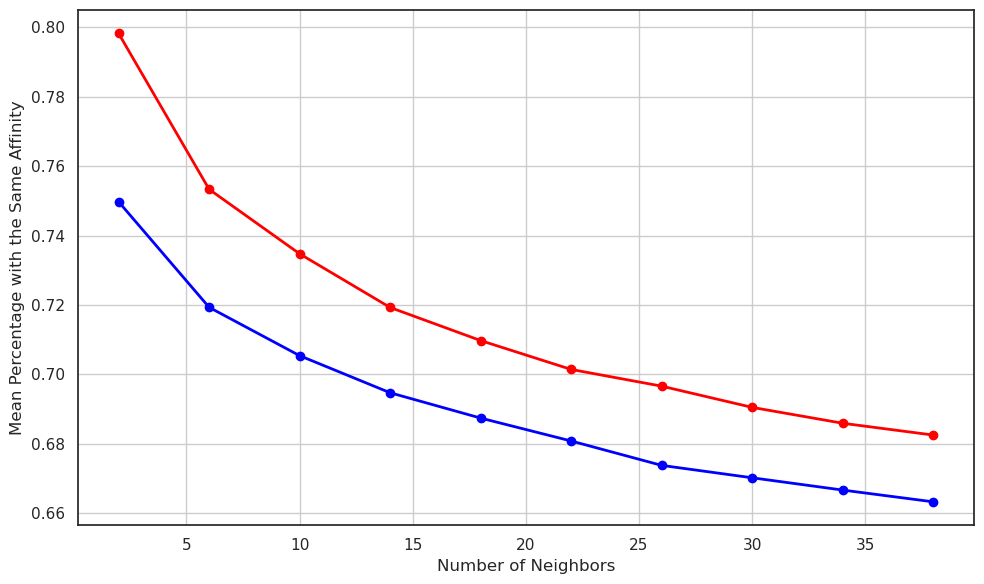

In [31]:
# Compute the mean fraction percentage for each neighbor number (affinity radius)
neighbor_numbers_esm2 = sorted(fractions_results_esm2.keys())
means_esm2 = [sum(fractions_results_esm2[n]) / len(fractions_results_esm2[n]) for n in neighbor_numbers]

neighbor_numbers_ab2 = sorted(fractions_results_ab2.keys())
means_ab2 = [sum(fractions_results_ab2[n]) / len(fractions_results_ab2[n]) for n in neighbor_numbers]

# Set up the matplotlib figure
plt.figure(figsize=(10, 6))

# Plotting the scatter plot with connected dots
plt.scatter(neighbor_numbers_esm2, means_esm2, color='blue', label='Mean Percentages')
plt.plot(neighbor_numbers_esm2, means_esm2, color='blue', linestyle='-', linewidth=2, markersize=5, label='Trendline')

plt.scatter(neighbor_numbers_ab2, means_ab2, color='red', label='Mean Percentages')
plt.plot(neighbor_numbers_ab2, means_ab2, color='red', linestyle='-', linewidth=2, markersize=5, label='Trendline')

# Add legend, labels, and title
#plt.legend(title='Metric')
plt.xlabel('Number of Neighbors')
plt.ylabel('Mean Percentage with the Same Affinity')
#plt.title('Mean Percentage of Sequences with the Same Affinity Label by Number of Neighbors')
plt.grid(True)

# Optionally set x and y limits
# plt.xlim(lower_limit, upper_limit)
# plt.ylim(lower_limit, upper_limit)

# Save the plot to a file and display it
plt.tight_layout()
plt.savefig('vicinity.png')  # Saved image file name
plt.show()

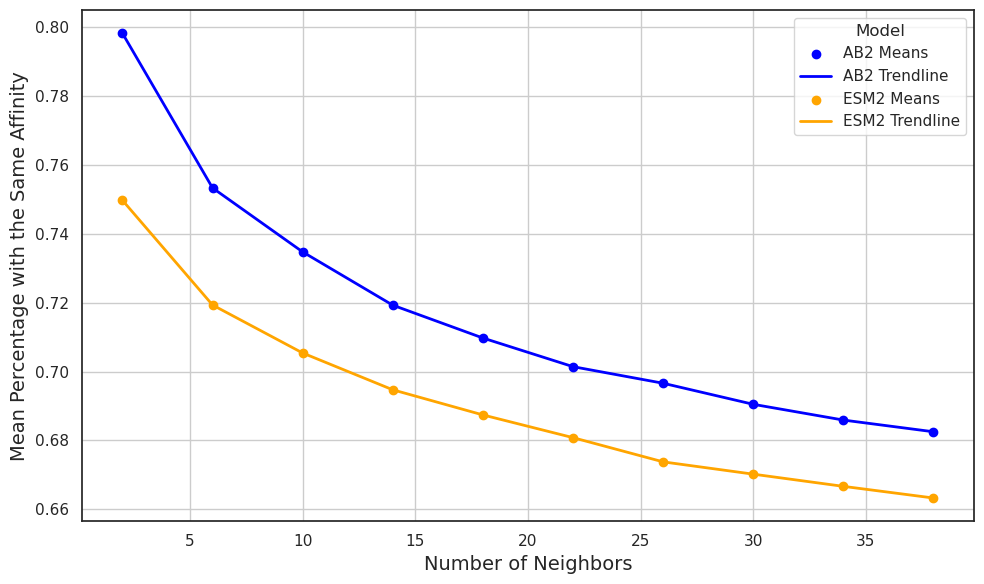

In [33]:
import matplotlib.pyplot as plt

# Compute the mean fraction percentage for each neighbor number (affinity radius)
neighbor_numbers_esm2 = sorted(fractions_results_esm2.keys())
means_esm2 = [sum(fractions_results_esm2[n]) / len(fractions_results_esm2[n]) for n in neighbor_numbers_esm2]

neighbor_numbers_ab2 = sorted(fractions_results_ab2.keys())
means_ab2 = [sum(fractions_results_ab2[n]) / len(fractions_results_ab2[n]) for n in neighbor_numbers_ab2]

# Set up the matplotlib figure
plt.figure(figsize=(10, 6))

# Plot AB2 means and trendline
plt.scatter(neighbor_numbers_ab2, means_ab2, color='blue', label='AB2 Means')
plt.plot(neighbor_numbers_ab2, means_ab2, color='blue', linestyle='-', linewidth=2, label='AB2 Trendline')

# Plot ESM2 means and trendline
plt.scatter(neighbor_numbers_esm2, means_esm2, color='orange', label='ESM2 Means')
plt.plot(neighbor_numbers_esm2, means_esm2, color='orange', linestyle='-', linewidth=2, label='ESM2 Trendline')

# Add legend, labels, and title
plt.legend(title='Model')
plt.xlabel('Number of Neighbors', fontsize=14)
plt.ylabel('Mean Percentage with the Same Affinity', fontsize=14)
# plt.title('Mean Percentage by Number of Neighbors', fontsize=16)
plt.grid(True)

# Save the plot to a file and display it
plt.tight_layout()
plt.savefig('ab2_vs_esm2_vicinity.png')  # Saved image file name
plt.show()
